# 02 — Speech Emotion Classification

**Objective**: Train a classifier on pre-extracted MFCC features from RAVDESS + CREMA-D  
to predict **speech emotion**, then map emotions to a **risk proxy**.  

**Rationale**: While wav2vec2 could extract deep embeddings directly from audio,  
our MFCC-based approach is computationally lighter and well-suited for the combined  
RAVDESS + CREMA-D dataset (8,882 samples). For the fusion engine, we map predicted  
emotions to risk levels (angry/sad/fearful/disgust -> higher risk).  

**Inputs**: `data/processed/speech_combined.csv` (96 MFCC + spectral features)  
**Outputs**: Trained model in `models/speech_classifier/`, metrics, confusion matrix.

In [1]:
# ── 0. Imports & Configuration ──────────────────────────────────────
import os, warnings, json, joblib
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from xgboost import XGBClassifier

# Paths
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DATA_DIR     = os.path.join(PROJECT_ROOT, 'data', 'processed')
MODEL_DIR    = os.path.join(PROJECT_ROOT, 'models', 'speech_classifier')
os.makedirs(MODEL_DIR, exist_ok=True)

SEED = 42
np.random.seed(SEED)

print(f'Data dir:  {DATA_DIR}')
print(f'Model dir: {MODEL_DIR}')

Data dir:  D:\EmoCare\data\processed
Model dir: D:\EmoCare\models\speech_classifier


## 1. Load & Inspect Data

In [2]:
# ── 1. Load combined speech features ────────────────────────────────
df = pd.read_csv(os.path.join(DATA_DIR, 'speech_combined.csv'), low_memory=False)

print(f'Total samples: {len(df):,}')
print(f'Columns: {len(df.columns)}')
print(f'\nSource distribution:')
print(df['source'].value_counts())
print(f'\nEmotion distribution:')
print(df['emotion'].value_counts())
print(f'\nSplit distribution:')
print(df['split'].value_counts())

Total samples: 8,882
Columns: 106

Source distribution:
source
CREMA-D    7442
RAVDESS    1440
Name: count, dtype: int64

Emotion distribution:
emotion
happy        1463
sad          1463
angry        1463
fearful      1463
disgust      1463
neutral      1183
calm          192
surprised     192
Name: count, dtype: int64

Split distribution:
split
train    6905
test     1000
val       977
Name: count, dtype: int64


In [3]:
# ── 1b. Identify feature vs metadata columns ──────────────────────
meta_cols = ['emotion', 'emotion_id', 'intensity', 'actor_id', 'gender',
             'modality', 'split', 'source', 'emotion_code', 'level']

feature_cols = [c for c in df.columns if c not in meta_cols]
print(f'Feature columns: {len(feature_cols)}')
print(f'First 10: {feature_cols[:10]}')
print(f'Last 10:  {feature_cols[-10:]}')

# Check for NaN in features
nan_counts = df[feature_cols].isna().sum()
if nan_counts.sum() > 0:
    print(f'\nWARNING: {nan_counts.sum()} NaN values in features')
    print(nan_counts[nan_counts > 0])
else:
    print(f'\nNo NaN values in feature columns.')

Feature columns: 96
First 10: ['mfcc_0_mean', 'mfcc_0_std', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std']
Last 10:  ['zcr_std', 'spectral_centroid_mean', 'spectral_centroid_std', 'spectral_bandwidth_mean', 'spectral_rolloff_mean', 'chroma_mean', 'chroma_std', 'duration_s', 'pause_ratio', 'filename']

No NaN values in feature columns.


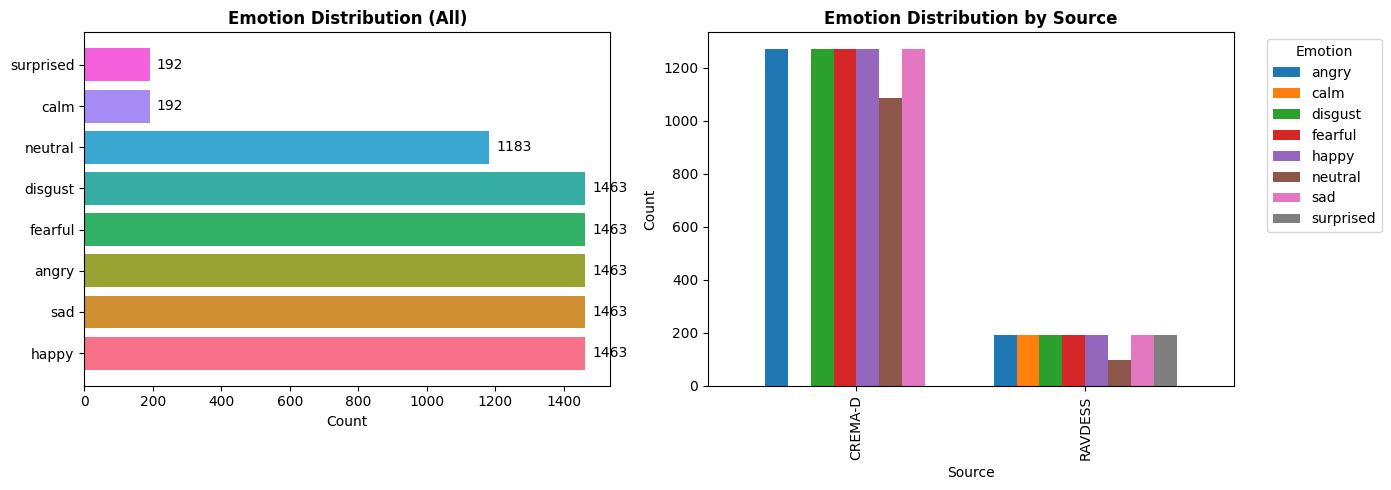

In [4]:
# ── 1c. Visualize emotion distribution ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall
emotion_counts = df['emotion'].value_counts()
colors = sns.color_palette('husl', len(emotion_counts))
axes[0].barh(emotion_counts.index, emotion_counts.values, color=colors)
axes[0].set_title('Emotion Distribution (All)', fontweight='bold')
axes[0].set_xlabel('Count')
for i, v in enumerate(emotion_counts.values):
    axes[0].text(v + 20, i, str(v), va='center')

# By source
source_emotion = df.groupby(['source', 'emotion']).size().unstack(fill_value=0)
source_emotion.plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_title('Emotion Distribution by Source', fontweight='bold')
axes[1].set_xlabel('Source')
axes[1].set_ylabel('Count')
axes[1].legend(title='Emotion', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'emotion_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 2. Prepare Features & Labels

In [5]:
# ── 2. Split data ──────────────────────────────────────────────────
train_df = df[df['split'] == 'train'].copy()
val_df   = df[df['split'] == 'val'].copy()
test_df  = df[df['split'] == 'test'].copy()

print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

# Encode emotion labels
le = LabelEncoder()
le.fit(df['emotion'])
print(f'\nEmotion classes ({len(le.classes_)}): {list(le.classes_)}')

# Prepare X, y
# Drop any non-numeric feature columns
numeric_feature_cols = [c for c in feature_cols if df[c].dtype in ['float64', 'float32', 'int64', 'int32']]
print(f'Numeric feature columns: {len(numeric_feature_cols)}')

X_train = train_df[numeric_feature_cols].values
X_val   = val_df[numeric_feature_cols].values
X_test  = test_df[numeric_feature_cols].values

y_train = le.transform(train_df['emotion'])
y_val   = le.transform(val_df['emotion'])
y_test  = le.transform(test_df['emotion'])

print(f'\nX_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}')

Train: 6,905 | Val: 977 | Test: 1,000



Emotion classes (8): ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Numeric feature columns: 95



X_train: (6905, 95), X_val: (977, 95), X_test: (1000, 95)


In [6]:
# ── 2b. Handle NaN and scale features ──────────────────────────────
# Replace any remaining NaN with column mean
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_val   = imputer.transform(X_val)
X_test  = imputer.transform(X_test)

# Standard scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f'Features scaled. Train mean: {X_train.mean():.4f}, std: {X_train.std():.4f}')

Features scaled. Train mean: 0.0000, std: 1.0000


## 3. Model Training — XGBoost + Random Forest

We train two models and pick the best one:
1. **XGBoost** — gradient boosted trees, strong on tabular data
2. **Random Forest** — ensemble baseline, robust and interpretable

In [7]:
# ── 3a. XGBoost ────────────────────────────────────────────────────
print('Training XGBoost...')
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    eval_metric='mlogloss',
    early_stopping_rounds=20,
    n_jobs=-1,
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

# Evaluate
xgb_val_pred = xgb_model.predict(X_val)
xgb_test_pred = xgb_model.predict(X_test)

xgb_val_f1 = f1_score(y_val, xgb_val_pred, average='macro')
xgb_test_f1 = f1_score(y_test, xgb_test_pred, average='macro')
xgb_test_acc = accuracy_score(y_test, xgb_test_pred)

print(f'\nXGBoost Results:')
print(f'  Val  F1 (macro): {xgb_val_f1:.4f}')
print(f'  Test F1 (macro): {xgb_test_f1:.4f}')
print(f'  Test Accuracy:   {xgb_test_acc:.4f}')

Training XGBoost...


[0]	validation_0-mlogloss:1.87720


[50]	validation_0-mlogloss:1.23207


[100]	validation_0-mlogloss:1.19485


[127]	validation_0-mlogloss:1.19803



XGBoost Results:
  Val  F1 (macro): 0.5556
  Test F1 (macro): 0.4807
  Test Accuracy:   0.5070


In [8]:
# ── 3b. Random Forest ──────────────────────────────────────────────
print('Training Random Forest...')
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)

# Evaluate
rf_val_pred = rf_model.predict(X_val)
rf_test_pred = rf_model.predict(X_test)

rf_val_f1 = f1_score(y_val, rf_val_pred, average='macro')
rf_test_f1 = f1_score(y_test, rf_test_pred, average='macro')
rf_test_acc = accuracy_score(y_test, rf_test_pred)

print(f'\nRandom Forest Results:')
print(f'  Val  F1 (macro): {rf_val_f1:.4f}')
print(f'  Test F1 (macro): {rf_test_f1:.4f}')
print(f'  Test Accuracy:   {rf_test_acc:.4f}')

Training Random Forest...



Random Forest Results:
  Val  F1 (macro): 0.5158
  Test F1 (macro): 0.4703
  Test Accuracy:   0.4740


D:\EmoCare\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
D:\EmoCare\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
D:\EmoCare\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
D:\EmoCare\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used w

In [9]:
# ── 3c. Select best model ──────────────────────────────────────────
print('\n' + '='*60)
print('MODEL COMPARISON')
print('='*60)
results_df = pd.DataFrame({
    'Model': ['XGBoost', 'Random Forest'],
    'Val F1 (macro)': [xgb_val_f1, rf_val_f1],
    'Test F1 (macro)': [xgb_test_f1, rf_test_f1],
    'Test Accuracy': [xgb_test_acc, rf_test_acc],
})
print(results_df.to_string(index=False))

# Pick the best based on test F1
if xgb_test_f1 >= rf_test_f1:
    best_model = xgb_model
    best_name = 'XGBoost'
    best_test_pred = xgb_test_pred
    best_test_f1 = xgb_test_f1
    best_test_acc = xgb_test_acc
else:
    best_model = rf_model
    best_name = 'RandomForest'
    best_test_pred = rf_test_pred
    best_test_f1 = rf_test_f1
    best_test_acc = rf_test_acc

print(f'\nBest model: {best_name} (Test F1: {best_test_f1:.4f})')


MODEL COMPARISON


        Model  Val F1 (macro)  Test F1 (macro)  Test Accuracy
      XGBoost        0.555618         0.480698          0.507
Random Forest        0.515820         0.470316          0.474

Best model: XGBoost (Test F1: 0.4807)


## 4. Detailed Evaluation

In [10]:
# ── 4a. Classification report ──────────────────────────────────────
print('\n' + '='*60)
print(f'CLASSIFICATION REPORT ({best_name})')
print('='*60)
print(classification_report(y_test, best_test_pred,
                            target_names=le.classes_, digits=4))


CLASSIFICATION REPORT (XGBoost)
              precision    recall  f1-score   support

       angry     0.7410    0.6280    0.6799       164
        calm     0.5333    0.3333    0.4103        24
     disgust     0.4526    0.5244    0.4859       164
     fearful     0.5085    0.3659    0.4255       164
       happy     0.5289    0.3902    0.4491       164
     neutral     0.5000    0.4015    0.4454       132
         sad     0.4357    0.7439    0.5495       164
   surprised     0.3548    0.4583    0.4000        24

    accuracy                         0.5070      1000
   macro avg     0.5069    0.4807    0.4807      1000
weighted avg     0.5247    0.5070    0.5030      1000



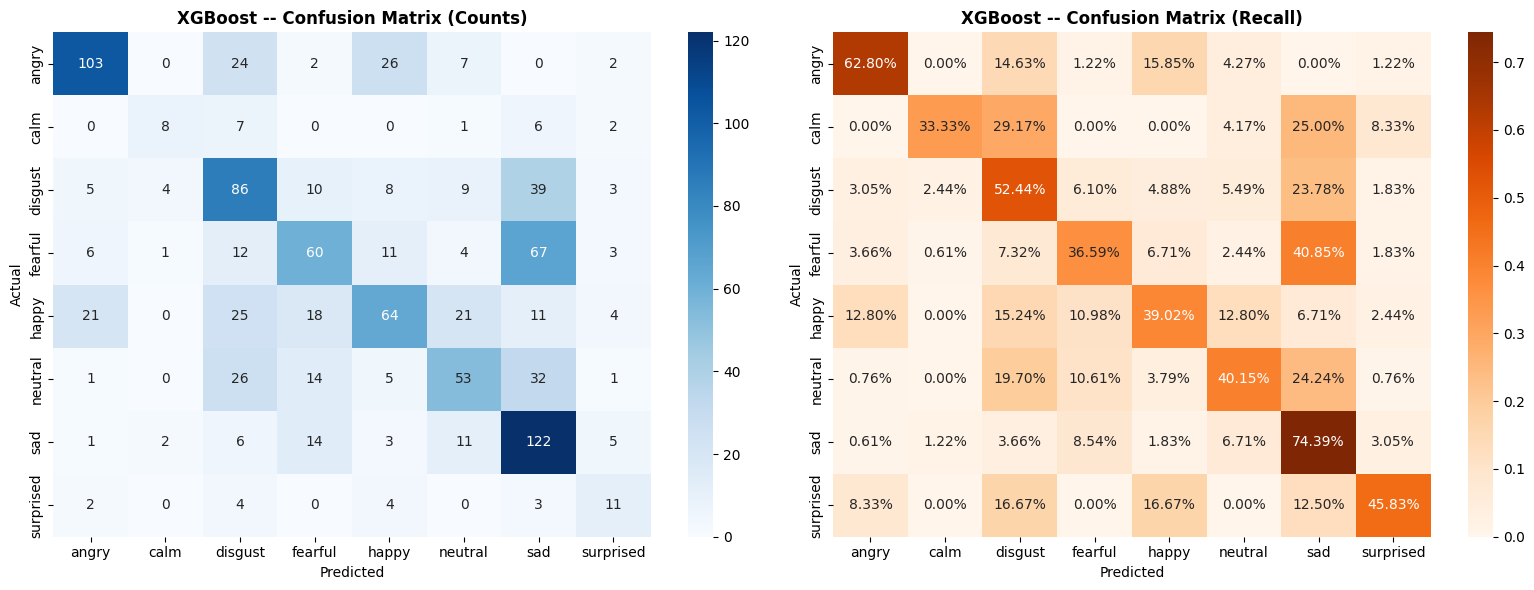

In [11]:
# ── 4b. Confusion matrix ───────────────────────────────────────────
cm = confusion_matrix(y_test, best_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title(f'{best_name} -- Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Normalised
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title(f'{best_name} -- Confusion Matrix (Recall)', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

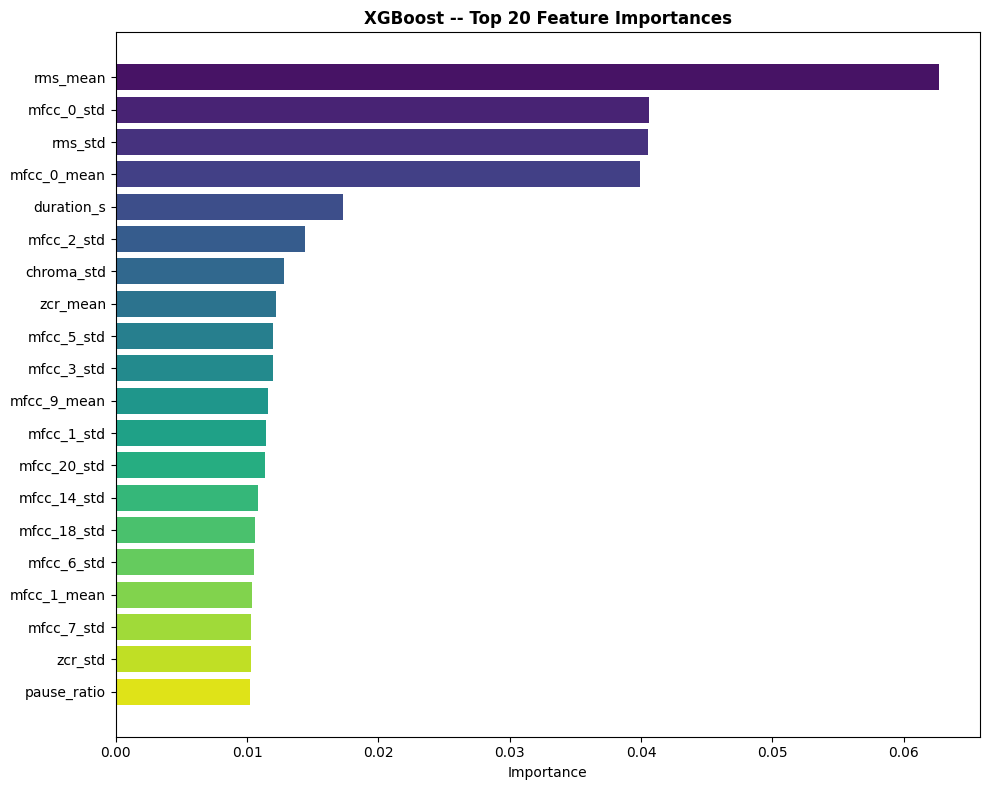

In [12]:
# ── 4c. Feature importance (top 20) ────────────────────────────────
if best_name == 'XGBoost':
    importances = best_model.feature_importances_
else:
    importances = best_model.feature_importances_

feat_imp = pd.DataFrame({
    'feature': numeric_feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_n = 20
top_features = feat_imp.head(top_n)
ax.barh(range(top_n), top_features['importance'].values, color=sns.color_palette('viridis', top_n))
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['feature'].values)
ax.invert_yaxis()
ax.set_title(f'{best_name} -- Top {top_n} Feature Importances', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Emotion-to-Risk Mapping

For the fusion engine, we need to convert speech emotions into risk probabilities.  
We define a mapping based on clinical literature:

| Emotion | Risk Level | Rationale |
|---|---|---|
| neutral, calm, happy, surprised | Low | Positive/neutral affect |
| fearful | Moderate | Anxiety indicator |
| angry, sad, disgust | High | Negative affect, distress markers |

In [13]:
# ── 5. Emotion -> Risk mapping ─────────────────────────────────────
EMOTION_TO_RISK = {
    'neutral':   0,  # Low
    'calm':      0,  # Low
    'happy':     0,  # Low
    'surprised': 0,  # Low
    'fearful':   1,  # Moderate
    'angry':     2,  # High
    'sad':       2,  # High
    'disgust':   2,  # High
}

RISK_NAMES = {0: 'Low', 1: 'Moderate', 2: 'High'}

def emotion_probs_to_risk_probs(emotion_probs, classes):
    """Convert emotion probability vector to 3-class risk probabilities.
    
    Args:
        emotion_probs: array of shape (n_classes,) with probability per emotion
        classes: list of emotion names in order
    
    Returns:
        dict with Low/Moderate/High probabilities
    """
    risk_probs = {0: 0.0, 1: 0.0, 2: 0.0}
    for emotion, prob in zip(classes, emotion_probs):
        risk_level = EMOTION_TO_RISK.get(emotion, 0)
        risk_probs[risk_level] += prob
    return {
        'Low': risk_probs[0],
        'Moderate': risk_probs[1],
        'High': risk_probs[2],
    }

# Demo: convert test predictions to risk
if hasattr(best_model, 'predict_proba'):
    test_emotion_probs = best_model.predict_proba(X_test)
    # Convert first 5 samples
    print('Emotion -> Risk mapping demo (first 5 test samples):')
    print('-' * 60)
    for i in range(5):
        true_emotion = le.inverse_transform([y_test[i]])[0]
        pred_emotion = le.inverse_transform([best_test_pred[i]])[0]
        risk = emotion_probs_to_risk_probs(test_emotion_probs[i], le.classes_)
        risk_label = max(risk, key=risk.get)
        print(f'  True: {true_emotion:10s} | Pred: {pred_emotion:10s} | '
              f'Risk: {risk_label} (L={risk["Low"]:.2f} M={risk["Moderate"]:.2f} H={risk["High"]:.2f})')
else:
    print('Model does not support predict_proba -- will use hard labels for risk mapping.')

Emotion -> Risk mapping demo (first 5 test samples):
------------------------------------------------------------
  True: neutral    | Pred: sad        | Risk: High (L=0.14 M=0.03 H=0.83)
  True: neutral    | Pred: disgust    | Risk: High (L=0.15 M=0.02 H=0.83)
  True: neutral    | Pred: disgust    | Risk: High (L=0.11 M=0.01 H=0.88)
  True: neutral    | Pred: disgust    | Risk: High (L=0.37 M=0.02 H=0.61)
  True: calm       | Pred: sad        | Risk: High (L=0.13 M=0.01 H=0.86)


## 6. Save Model & Artifacts

In [14]:
# ── 6. Save everything ─────────────────────────────────────────────
# Save model
joblib.dump(best_model, os.path.join(MODEL_DIR, 'speech_emotion_model.joblib'))
joblib.dump(scaler, os.path.join(MODEL_DIR, 'scaler.joblib'))
joblib.dump(imputer, os.path.join(MODEL_DIR, 'imputer.joblib'))
joblib.dump(le, os.path.join(MODEL_DIR, 'label_encoder.joblib'))

# Save metrics
metrics = {
    'model_type': best_name,
    'task': 'speech_emotion_classification',
    'num_classes': len(le.classes_),
    'classes': list(le.classes_),
    'emotion_to_risk_map': {k: RISK_NAMES[v] for k, v in EMOTION_TO_RISK.items()},
    'feature_columns': numeric_feature_cols,
    'test_metrics': {
        'accuracy': round(best_test_acc, 4),
        'f1_macro': round(best_test_f1, 4),
    },
    'classification_report': classification_report(
        y_test, best_test_pred, target_names=le.classes_, output_dict=True
    ),
    'model_comparison': {
        'xgboost_test_f1': round(xgb_test_f1, 4),
        'random_forest_test_f1': round(rf_test_f1, 4),
    },
}

with open(os.path.join(MODEL_DIR, 'metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2)

print(f'Model saved to: {MODEL_DIR}')
print(f'\nSaved files:')
for f_name in sorted(os.listdir(MODEL_DIR)):
    fpath = os.path.join(MODEL_DIR, f_name)
    if os.path.isfile(fpath):
        size_mb = os.path.getsize(fpath) / 1024 / 1024
        print(f'  {f_name:40s} {size_mb:8.2f} MB')

Model saved to: D:\EmoCare\models\speech_classifier

Saved files:
  confusion_matrix.png                         0.18 MB
  emotion_distribution.png                     0.07 MB
  feature_importance.png                       0.06 MB
  imputer.joblib                               0.00 MB
  label_encoder.joblib                         0.00 MB
  metrics.json                                 0.00 MB
  scaler.joblib                                0.00 MB
  speech_emotion_model.joblib                  5.21 MB


## 7. Summary

| Item | Detail |
|---|---|
| **Models trained** | XGBoost + Random Forest (best selected) |
| **Task** | 8-class speech emotion classification |
| **Data** | RAVDESS + CREMA-D combined (8,882 samples, 96 MFCC features) |
| **Risk mapping** | Emotions mapped to Low/Moderate/High for fusion |
| **Output** | `models/speech_classifier/` -- ready for fusion |

**Next**: Notebook 03 -- Behavioral modeling + multimodal late fusion.